<a href="https://colab.research.google.com/github/Saifullah785/Predictive_Maintenance_ML_Projects/blob/main/Project_01_Predictive_Maintenance_Using_Machine_Learning/Project_01_Predictive_Maintenance_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import accuracy_score, classification_report, recall_score, precision_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Define the column names
column_names = ['Temperature', 'Vibration', 'Pressure', 'Humidity', 'RPM', 'Voltage', 'Current', 'Sound_Level', 'Oil_Quality', 'Load','Machine Type','Failure Type','Component Type']

# Generate random data for each column
num_rows = 100
data = {
    'Temperature': np.random.uniform(20, 100, num_rows),  # Temperature between 20 and 100
    'Vibration': np.random.uniform(0, 1, num_rows),  # Vibration between 0 and 1
    'Pressure': np.random.uniform(1, 10, num_rows),  # Pressure between 1 and 10
    'Humidity': np.random.uniform(30, 80, num_rows),  # Humidity between 30 and 80
    'RPM': np.random.uniform(1000, 5000, num_rows),  # RPM between 1000 and 5000
    'Voltage': np.random.uniform(110, 240, num_rows),  # Voltage between 110 and 240
    'Current': np.random.uniform(1, 10, num_rows),  # Current between 1 and 10
    'Sound_Level': np.random.uniform(60, 100, num_rows),  # Sound level between 60 and 100
    'Oil_Quality': np.random.uniform(0, 1, num_rows),  # Oil quality between 0 and 1
    'Load': np.random.uniform(0, 100, num_rows),  # Load between 0 and 100
    'Machine Type': np.random.choice(['Pump', 'Motor', 'Compressor', 'Turbine'], num_rows),  # Randomly assigns one of the four machine types to each row
    'Failure Type': np.random.choice(['Overheating', 'Vibration, Wear', 'Electrical', 'No Failure'], num_rows),  # Randomly assigns one of the four failure types to each row
    'Component Type': np.random.choice(['Bearing', 'Gear', 'Seal', 'Fan Blade'], num_rows)  # Randomly assigns one of the four component types to each row
}

# Combine columns to the data to create the dataset
pred = pd.DataFrame(data, columns=column_names)



In [3]:
pred.head()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load,Machine Type,Failure Type,Component Type
0,64.408935,0.410574,5.950775,77.663876,1123.752588,152.799551,6.768891,85.011894,0.357880,63.404982,Compressor,Electrical,Bearing
1,32.392421,0.652066,4.392681,79.315554,3953.570864,239.410022,2.917272,61.196081,0.717588,16.574873,Pump,"Vibration, Wear",Bearing
2,37.093304,0.917189,1.827306,47.361088,3082.053031,121.581805,8.206509,65.208448,0.103717,60.064295,Motor,No Failure,Bearing
3,82.244559,0.043486,1.770525,44.700310,1567.114313,120.069597,7.529393,64.066057,0.840205,81.311583,Turbine,No Failure,Bearing
4,43.167120,0.960602,3.115439,52.229161,2447.503729,112.152456,3.955605,70.684479,0.485986,43.233979,Motor,Electrical,Bearing


In [4]:
pred.tail()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load,Machine Type,Failure Type,Component Type
95,24.958503,0.696571,7.121717,68.549829,1363.924592,184.819601,7.158697,72.754662,0.984578,32.849051,Pump,No Failure,Fan Blade
96,88.577016,0.657257,6.700566,68.359467,2638.594122,143.819874,4.595087,86.466242,0.205325,57.865393,Pump,"Vibration, Wear",Seal
97,68.193481,0.156646,5.046930,47.967767,2285.201685,124.614723,7.937354,64.706997,0.233500,74.239838,Motor,Overheating,Fan Blade
98,39.457831,0.781245,6.689824,75.825523,3572.982767,200.401120,3.213029,81.996698,0.868108,87.033717,Motor,Electrical,Fan Blade
99,55.758397,0.462037,3.673558,31.651413,3376.990062,202.331577,1.997627,81.647563,0.806896,61.104227,Pump,"Vibration, Wear",Bearing


# **Exploratory Data Analysis**

In [5]:
pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     100 non-null    float64
 1   Vibration       100 non-null    float64
 2   Pressure        100 non-null    float64
 3   Humidity        100 non-null    float64
 4   RPM             100 non-null    float64
 5   Voltage         100 non-null    float64
 6   Current         100 non-null    float64
 7   Sound_Level     100 non-null    float64
 8   Oil_Quality     100 non-null    float64
 9   Load            100 non-null    float64
 10  Machine Type    100 non-null    object 
 11  Failure Type    100 non-null    object 
 12  Component Type  100 non-null    object 
dtypes: float64(10), object(3)
memory usage: 10.3+ KB


In [6]:
pred.describe()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,63.520409,0.507979,5.542038,56.400127,2875.185192,168.290999,5.501728,79.953224,0.455688,48.412686
std,22.845774,0.285039,2.538515,15.698710,1179.612752,36.764360,2.555728,11.234516,0.306649,27.810264
min,20.444423,0.007221,1.156908,30.031706,1026.098480,112.152456,1.078064,60.354628,0.008509,1.925863
25%,41.429943,0.272990,3.428574,41.754757,1828.390723,133.198502,3.264783,70.683004,0.196912,23.642080
50%,64.300321,0.496254,5.356214,57.213130,2678.379087,163.731720,5.347373,80.609752,0.399055,47.020696
75%,84.993309,0.738560,7.657431,69.417441,3796.362717,198.212255,7.795452,90.303137,0.703080,71.107603
max,99.866390,0.980598,9.942805,79.927553,4989.873530,239.410022,9.989916,99.564187,0.997185,98.840736


             Temperature  Vibration  Pressure  Humidity       RPM   Voltage  \
Temperature     1.000000  -0.052592 -0.022261 -0.137503  0.095782  0.064737   
Vibration      -0.052592   1.000000 -0.015016 -0.044496 -0.029213 -0.133771   
Pressure       -0.022261  -0.015016  1.000000 -0.027503  0.120430  0.100544   
Humidity       -0.137503  -0.044496 -0.027503  1.000000 -0.028335  0.002881   
RPM             0.095782  -0.029213  0.120430 -0.028335  1.000000  0.162890   
Voltage         0.064737  -0.133771  0.100544  0.002881  0.162890  1.000000   
Current         0.099517  -0.110739 -0.100704 -0.134183  0.128701 -0.060224   
Sound_Level    -0.019304   0.182364  0.080076  0.020912 -0.066596 -0.044509   
Oil_Quality     0.046265  -0.111436 -0.045374  0.076389  0.002627 -0.017117   
Load           -0.116146  -0.092983  0.038025  0.076540 -0.136227  0.045545   

              Current  Sound_Level  Oil_Quality      Load  
Temperature  0.099517    -0.019304     0.046265 -0.116146  
Vibration 

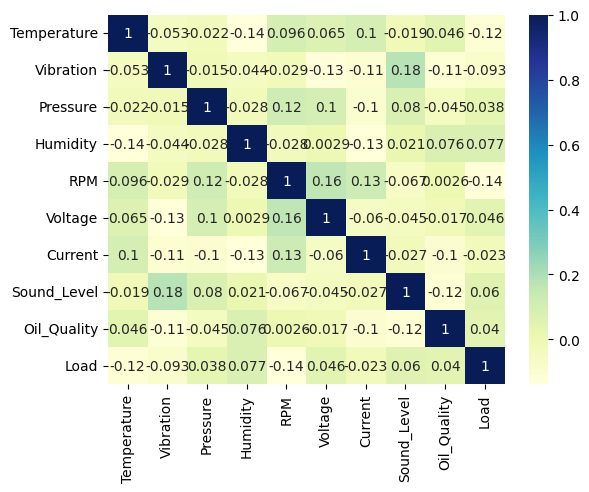

In [7]:
co_mtx = pred.corr(numeric_only=True)

print(co_mtx)

sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

plt.show()

# **Random Forest**

In [8]:
for col in pred:
  if pred[col].dtype == 'O':
    codes, _ = pd.factorize(pred[col])
    pred[col] = codes

In [9]:
X = pred[['Temperature', 'Vibration', 'Pressure', 'Humidity', 'RPM', 'Voltage', 'Current', 'Sound_Level', 'Oil_Quality','Load',
          'Failure Type','Component Type','Machine Type']]
y = pred['Component Type']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred, average='weighted'))
print('Precision:', precision_score(y_test, y_pred, average='weighted'))
print('F1 Score:', f1_score(y_test, y_pred, average='weighted'))
print('classification_report:')
print(classification_report(y_test, y_pred))

Accuracy: 1.0
Recall: 1.0
Precision: 1.0
F1 Score: 1.0
classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         9

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [12]:
model = RandomForestRegressor(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Mean Absolute Error:', np.mean(np.abs(y_test - y_pred)))

Mean Absolute Error: 0.0


# **Bagging**

In [13]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier(random_state=42))])

In [14]:
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred, average='weighted'))
print('Precision:', precision_score(y_test, y_pred, average='weighted'))
print('F1 Score:', f1_score(y_test, y_pred, average='weighted'))
print('classification_report:')
print(classification_report(y_test, y_pred))

Accuracy: 1.0
Recall: 1.0
Precision: 1.0
F1 Score: 1.0
classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         9

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [15]:
cv = cross_val_score(pipeline, X, y, cv=10)

print(f"Cross-validation scores: {cv}")
print(f"Mean CV accuracy: {np.mean(cv):.2f}")

Cross-validation scores: [1.  1.  1.  0.9 0.8 1.  1.  0.8 0.9 1. ]
Mean CV accuracy: 0.94


In [16]:
bagging_classifier = BaggingClassifier(estimator=pipeline, n_estimators=150, random_state=42)

bagging_classifier.fit(X_train, y_train)

BaggingClassifier(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                            ('classifier',
                                             RandomForestClassifier(random_state=42))]),
                  n_estimators=150, random_state=42)